In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Walk up from cwd until we find pyproject.toml (Jupyter sets cwd to the notebook
# folder, so the repo root is not cwd).
project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import analysis
from src import label_switching as ls

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 5)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Load Posterior Draws ──────────
# This notebook lives in <run>/ ; all artifacts live in <run>/results/.

def _resolve_run_dir():
    # VS Code injects __vsc_ipynb_file__ with the notebook's absolute path.
    nb = globals().get("__vsc_ipynb_file__")
    if nb:
        return pathlib.Path(nb).resolve().parent
    return pathlib.Path.cwd()

RUN_DIR     = _resolve_run_dir()
RESULTS_DIR = RUN_DIR / "results"
meta_path   = RESULTS_DIR / "meta.json"

if not meta_path.exists():
    raise FileNotFoundError(
        f"meta.json not found in:\n  {RESULTS_DIR}\n\n"
        f"This notebook must live in a run folder with artifacts in a results/ subfolder.\n"
        f"If you are in VS Code and this fails, set\n"
        f"  \"jupyter.notebookFileRoot\": \"${{fileDirname}}\"\n"
        f"so the working directory is the notebook's own folder, then restart the kernel."
    )

with open(meta_path) as f:
    meta = json.load(f)

SCENARIO_NAME = meta["scenario"]
K_MODEL       = int(meta["k_model"])
K_TRUE        = int(meta["k_true"])
SAMPLER       = meta["sampler"]
CHAINS        = int(meta["chains"])

with open(RESULTS_DIR / "posterior_raw.pkl", "rb") as f:
    posterior_samples = pickle.load(f)

print(f"Run folder : {RUN_DIR}")
print(f"Scenario   : {SCENARIO_NAME}   sampler: {SAMPLER}   chains: {CHAINS}")
print(f"K_MODEL    : {K_MODEL}   K_TRUE : {K_TRUE}")
print("\nPosterior arrays:")
for key, val in posterior_samples.items():
    print(f"   {key:<28} {np.asarray(val).shape}")

Run folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\2_chains\2_comp\NUTS\2comp_equal_K5_seed42
Scenario   : 2comp_equal   sampler: nuts   chains: 2
K_MODEL    : 5   K_TRUE : 2

Posterior arrays:
   Delta                        (2, 10000, 2, 4)
   beta_i                       (2, 10000, 300, 4)
   mu_k                         (2, 10000, 5, 4)
   pvec_latent                  (2, 10000, 4)
   sigma_inv_chol_k_latent      (2, 10000, 5, 10)


In [3]:
# ── Cell 3 : Ground Truth & Demographics ──────────
# Z is needed to reconstruct allocations via the household-specific mean
# mu_k + Z_i @ Delta (Rossi Eq. 5.5.19).
data_path = project_root / "data" / "simulated" / "mixture" / f"{SCENARIO_NAME}.json"
with open(data_path) as f:
    raw_data = json.load(f)

t_pvec = np.array(raw_data["TRUE_PVEC"]) if raw_data.get("TRUE_PVEC") is not None else None
Z      = np.array(raw_data["Z"]) if raw_data.get("Z") is not None else None

print(f"Ground truth from {data_path.name}")
if t_pvec is not None:
    print(f"TRUE_PVEC : {t_pvec.round(4)}")

Ground truth from 2comp_equal.json
TRUE_PVEC : [0.5 0.5]


In [4]:
# ── Cell 4 : ECR Relabeling of pvec ──────────
# ECR iterative version 1 (Papastamoulis 2016, Algorithm 5). Allocations are
# reconstructed from mu_k + Z@Delta, Sigma_k, pvec and beta_i (Liesel
# marginalizes them), so the same method serves NUTS / HMC / bayesm.
# ONLY pvec is post-processed - everything else stays label-invariant.
pvec_before = np.asarray(analysis._recover_pvec(posterior_samples))   # (C,S,K)
pvec_after, report = ls.relabel_pvec(posterior_samples, K=K_MODEL, Z=Z, K_true=K_TRUE)

print(f"ECR converged   : {report['converged']}  (in {report['n_iter']} sweeps)")
print(f"switching rate  : {report['switching_rate']:.3f}  (fraction of draws relabeled)")

ECR converged   : True  (in 3 sweeps)
switching rate  : 0.702  (fraction of draws relabeled)


Per-slot R-hat / ESS - BEFORE:


,stage,slot,live,rhat,ess
0,before,2,True,1.840,3.771
1,before,0,True,2.225,2.536
2,before,4,False,2.231,2.769
3,before,3,False,2.190,3.216
4,before,1,False,1.906,34.925


Per-slot R-hat / ESS - AFTER:


,stage,slot,live,rhat,ess
0,after,0,True,2.242,3.280
1,after,1,True,1.840,3.771
2,after,2,False,1.243,272.045
3,after,3,False,1.084,223.429
4,after,4,False,1.122,477.904


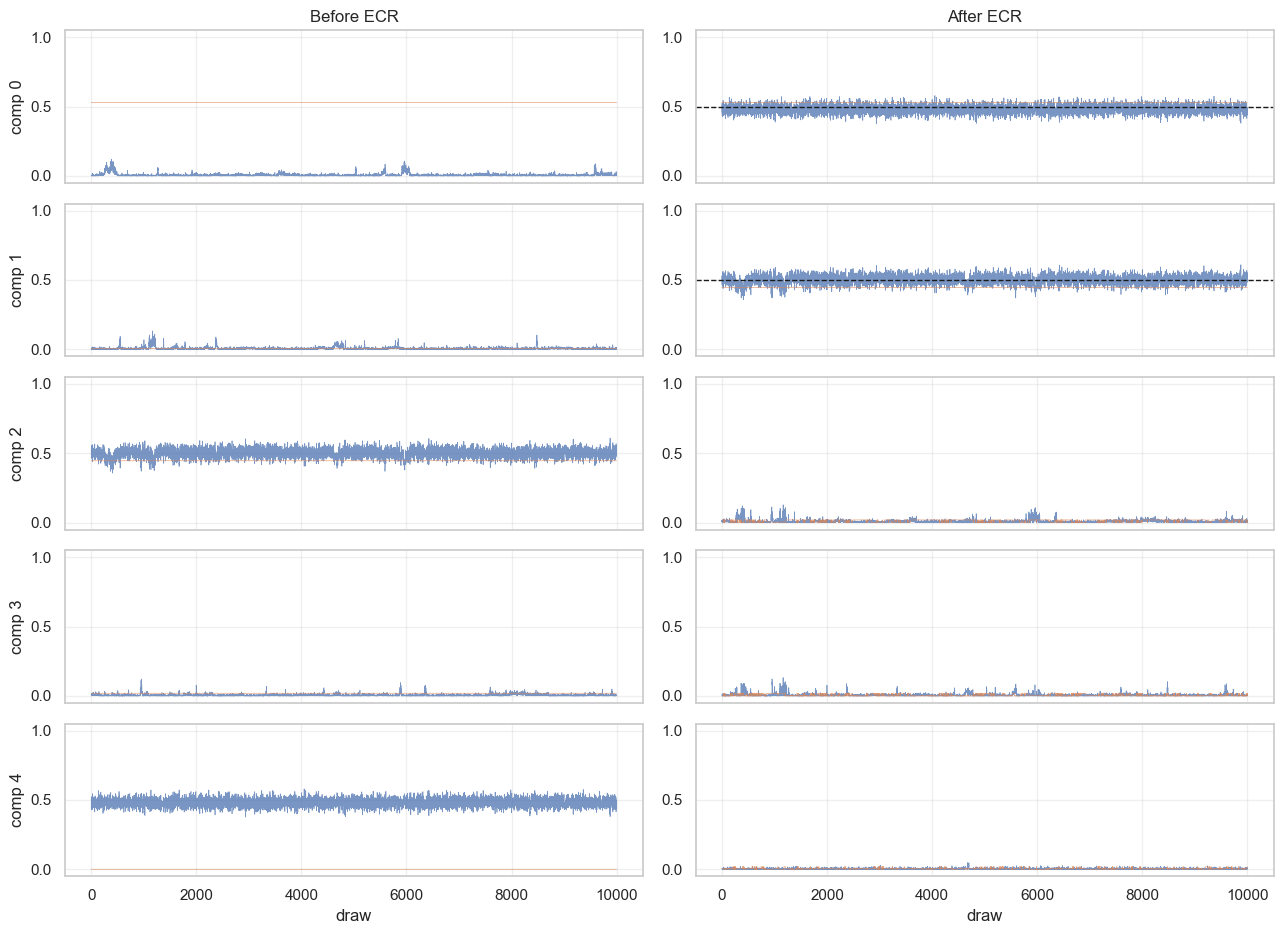

In [5]:
# ── Cell 5 : pvec R-hat / ESS and Traces - Before / After Relabeling ──────────
print("Per-slot R-hat / ESS - BEFORE:")
display(ls.pvec_convergence_table(pvec_before, K_MODEL, K_TRUE, label="before").round(3))
print("Per-slot R-hat / ESS - AFTER:")
display(ls.pvec_convergence_table(pvec_after, K_MODEL, K_TRUE, label="after").round(3))

# y-axis fixed to (-0.05, 1.05) to match the analysis notebook's pvec traces.
ls.plot_before_after_traces(pvec_before, pvec_after, K_MODEL,
                            true_vals=t_pvec, ylim=(-0.05, 1.05))